In [34]:
from datasets import load_dataset

corpus_name = "LouisDo2108/marqo_gs_wfash_1m_corpus_tevatron"
test_name = "LouisDo2108/marqo_gs_wfash_1m_tevatron"

In [36]:
corpus = load_dataset(corpus_name, split="train") # 518533 unique docids
test = load_dataset(test_name, split="test") # 131699 unique docids

In [50]:
all_test_docids = set([x
    for xs in test["positive_document_ids"]
    for x in xs
])
docid_to_idx = {docid: i for i, docid in enumerate(corpus["docid"])}
qid_to_idx = {qid: i for i, qid in enumerate(test["query_id"])}

In [66]:
item

{'docid': '17995334676127444394',
 'image': <PIL.WebPImagePlugin.WebPImageFile image mode=RGB size=453x453>,
 'title': "Betsey Johnson Kyla Bootie | Women's | Silver Metallic/Iridescent | Size 8 ...",
 'file_name': None}

Abound Denton Platform Bootie in Black at Nordstrom Rack, Size 8.5


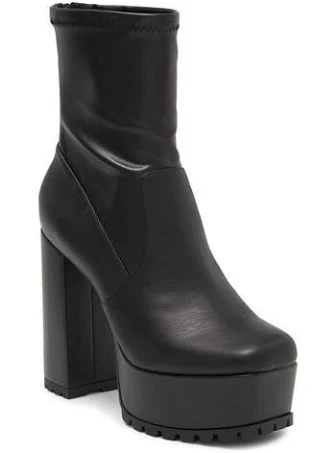

In [68]:
item = corpus[docid_to_idx["7804404988612200076"]]
print(item['title'])
item['image']

Heeled boots


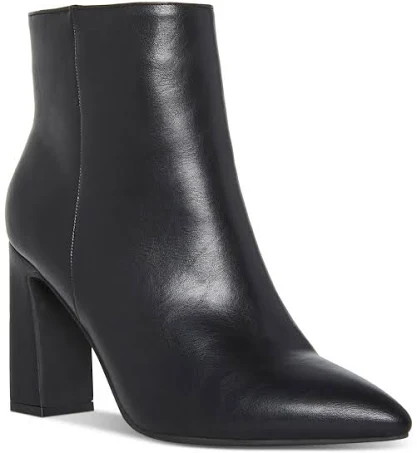

In [69]:
rank1_item_docid = test[qid_to_idx["1000"]]['positive_document_ids']
print(test[qid_to_idx["1000"]]['query'])
corpus[docid_to_idx[rank1_item_docid[1]]]['image']

In [ ]:
# test_docids_idx_in_corpus = [docid_to_idx[docid] for docid in all_test_docids]
# test_corpus_subset = corpus.select(test_docids_idx_in_corpus)
# test_corpus_subset.push_to_hub("LouisDo2108/marqo_gs_wfash_1m_test_subset_corpus_tevatron")

In [41]:
test['positive_document_ids']

Column([['6036566319049433640', '2864747716351999839', '7804404988612200076', '13182380686550770541', '7944394385775531732', '12344470624419177569', '5995359657459985369', '4351154148825069477', '14318728381539324249', '5546883145442036827', '6269683114810948302', '17933282827683401835', '8954418815543048909', '16098793512491619218', '17532833395026960844', '17833326755466801164', '2783159401350532842', '6797435327457602156', '6964233596172980407', '13699143548346060592', '3201607460403864272', '10076490730324117106', '13327775105892228072', '9169649232168320954', '13203117380224643547', '11849239610938028235', '18287181167859973825', '538188970240115770', '2440186506754254473', '8681947450035203584', '3203714423147531491', '17906377800390128410', '18231112386584976550', '5368543261599793054', '13065946721713099998', '4620655015365719686', '8749883419260353727', '543431000196758518', '12117018612660315341', '10418034892227928696', '7248656933439903797', '4584974718165803422', '48698666

In [70]:
with open("/home/thuy0050/mg61_scratch2/thuy0050/data/vlmcl/marqo/marqo_qrel_v2.txt", "w") as f:
    for i, row in enumerate(test):
        qid = row["query_id"]
        max_relevance_score = len(row["positive_document_ids"])
        for ix, pos_docids in enumerate(row["positive_document_ids"]):
            # f.write(f"{qid} 0 {pos_docids} {max_relevance_score - ix}\n")
            f.write(f"{qid} 0 {pos_docids} 1\n")

In [14]:
import torch
import torch.nn.functional as F
import numpy as np

PADDED_Y_VALUE = -1
DEFAULT_EPS = 1e-10

# Source: https://github.com/allegro/allRank/tree/master

def sinkhorn_scaling(mat, mask=None, tol=1e-6, max_iter=50):
    """
    Sinkhorn scaling procedure.
    :param mat: a tensor of square matrices of shape N x M x M, where N is batch size
    :param mask: a tensor of masks of shape N x M
    :param tol: Sinkhorn scaling tolerance
    :param max_iter: maximum number of iterations of the Sinkhorn scaling
    :return: a tensor of (approximately) doubly stochastic matrices
    """
    if mask is not None:
        mat = mat.masked_fill(mask[:, None, :] | mask[:, :, None], 0.0)
        mat = mat.masked_fill(mask[:, None, :] & mask[:, :, None], 1.0)

    for _ in range(max_iter):
        mat = mat / mat.sum(dim=1, keepdim=True).clamp(min=DEFAULT_EPS)
        mat = mat / mat.sum(dim=2, keepdim=True).clamp(min=DEFAULT_EPS)

        if torch.max(torch.abs(mat.sum(dim=2) - 1.)) < tol and torch.max(torch.abs(mat.sum(dim=1) - 1.)) < tol:
            break

    if mask is not None:
        mat = mat.masked_fill(mask[:, None, :] | mask[:, :, None], 0.0)

    return mat


def deterministic_neural_sort(s, tau, mask, device):
    """
    Deterministic neural sort.
    Code taken from "Stochastic Optimization of Sorting Networks via Continuous Relaxations", ICLR 2019.
    Minor modifications applied to the original code (masking).
    :param s: values to sort, shape [batch_size, slate_length]
    :param tau: temperature for the final softmax function
    :param mask: mask indicating padded elements
    :return: approximate permutation matrices of shape [batch_size, slate_length, slate_length]
    """
    dev = device

    n = s.size()[1]
    one = torch.ones((n, 1), dtype=torch.float32, device=device)
    s = s.masked_fill(mask[:, :, None], -1e8)
    A_s = torch.abs(s - s.permute(0, 2, 1))
    A_s = A_s.masked_fill(mask[:, :, None] | mask[:, None, :], 0.0)

    B = torch.matmul(A_s, torch.matmul(one, torch.transpose(one, 0, 1)))

    temp = [n - m + 1 - 2 * (torch.arange(n - m, device=dev) + 1) for m in mask.squeeze(-1).sum(dim=1)]
    temp = [t.type(torch.float32) for t in temp]
    temp = [torch.cat((t, torch.zeros(n - len(t), device=dev))) for t in temp]
    scaling = torch.stack(temp).type(torch.float32).to(dev)  # type: ignore

    s = s.masked_fill(mask[:, :, None], 0.0)
    C = torch.matmul(s, scaling.unsqueeze(-2))

    P_max = (C - B).permute(0, 2, 1)
    P_max = P_max.masked_fill(mask[:, :, None] | mask[:, None, :], -np.inf)
    P_max = P_max.masked_fill(mask[:, :, None] & mask[:, None, :], 1.0)
    sm = torch.nn.Softmax(-1)
    P_hat = sm(P_max / tau)
    return P_hat


def sample_gumbel(samples_shape, device, eps=1e-10) -> torch.Tensor:
    """
    Sampling from Gumbel distribution.
    Code taken from "Stochastic Optimization of Sorting Networks via Continuous Relaxations", ICLR 2019.
    Minor modifications applied to the original code (masking).
    :param samples_shape: shape of the output samples tensor
    :param device: device of the output samples tensor
    :param eps: epsilon for the logarithm function
    :return: Gumbel samples tensor of shape samples_shape
    """
    U = torch.rand(samples_shape, device=device)
    return -torch.log(-torch.log(U + eps) + eps)


def stochastic_neural_sort(s, n_samples, tau, mask, device, beta=1.0, log_scores=True, eps=1e-10):
    """
    Stochastic neural sort. Please note that memory complexity grows by factor n_samples.
    Code taken from "Stochastic Optimization of Sorting Networks via Continuous Relaxations", ICLR 2019.
    Minor modifications applied to the original code (masking).
    :param s: values to sort, shape [batch_size, slate_length]
    :param n_samples: number of samples (approximations) for each permutation matrix
    :param tau: temperature for the final softmax function
    :param mask: mask indicating padded elements
    :param beta: scale parameter for the Gumbel distribution
    :param log_scores: whether to apply the logarithm function to scores prior to Gumbel perturbation
    :param eps: epsilon for the logarithm function
    :return: approximate permutation matrices of shape [n_samples, batch_size, slate_length, slate_length]
    """
    dev = device

    batch_size = s.size()[0]
    n = s.size()[1]
    s_positive = s + torch.abs(s.min())
    samples = beta * sample_gumbel([n_samples, batch_size, n, 1], device=dev)
    if log_scores:
        s_positive = torch.log(s_positive + eps)

    s_perturb = (s_positive + samples).view(n_samples * batch_size, n, 1)
    mask_repeated = mask.repeat_interleave(n_samples, dim=0)

    P_hat = deterministic_neural_sort(s_perturb, tau, mask_repeated, device=dev)
    P_hat = P_hat.view(n_samples, batch_size, n, n)
    return P_hat


def __apply_mask_and_get_true_sorted_by_preds(y_pred, y_true, padding_indicator=PADDED_Y_VALUE):
    mask = y_true == padding_indicator

    y_pred[mask] = float('-inf')
    y_true[mask] = 0.0

    _, indices = y_pred.sort(descending=True, dim=-1)
    return torch.gather(y_true, dim=1, index=indices)


def dcg(y_pred, y_true, ats=None, gain_function=lambda x: torch.pow(2, x) - 1, padding_indicator=PADDED_Y_VALUE):
    """
    Discounted Cumulative Gain at k.

    Compute DCG at ranks given by ats or at the maximum rank if ats is None.
    :param y_pred: predictions from the model, shape [batch_size, slate_length]
    :param y_true: ground truth labels, shape [batch_size, slate_length]
    :param ats: optional list of ranks for DCG evaluation, if None, maximum rank is used
    :param gain_function: callable, gain function for the ground truth labels, e.g. torch.pow(2, x) - 1
    :param padding_indicator: an indicator of the y_true index containing a padded item, e.g. -1
    :return: DCG values for each slate and evaluation position, shape [batch_size, len(ats)]
    """
    y_true = y_true.clone()
    y_pred = y_pred.clone()

    actual_length = y_true.shape[1]

    if ats is None:
        ats = [actual_length]
    ats = [min(at, actual_length) for at in ats]

    true_sorted_by_preds = __apply_mask_and_get_true_sorted_by_preds(y_pred, y_true, padding_indicator)

    discounts = (torch.tensor(1) / torch.log2(torch.arange(true_sorted_by_preds.shape[1], dtype=torch.float) + 2.0)).to(
        device=true_sorted_by_preds.device)

    gains = gain_function(true_sorted_by_preds)

    discounted_gains = (gains * discounts)[:, :np.max(ats)]

    cum_dcg = torch.cumsum(discounted_gains, dim=1)

    ats_tensor = torch.tensor(ats, dtype=torch.long) - torch.tensor(1)

    dcg = cum_dcg[:, ats_tensor]

    return dcg


def neuralNDCG(y_pred, y_true, padded_value_indicator=PADDED_Y_VALUE, temperature=1., powered_relevancies=True, k=None,
               stochastic=False, n_samples=32, beta=0.1, log_scores=True, device="cuda"):
    """
    NeuralNDCG loss introduced in "NeuralNDCG: Direct Optimisation of a Ranking Metric via Differentiable
    Relaxation of Sorting" - https://arxiv.org/abs/2102.07831. Based on the NeuralSort algorithm.
    :param y_pred: predictions from the model, shape [batch_size, slate_length]
    :param y_true: ground truth labels, shape [batch_size, slate_length]
    :param padded_value_indicator: an indicator of the y_true index containing a padded item, e.g. -1
    :param temperature: temperature for the NeuralSort algorithm
    :param powered_relevancies: whether to apply 2^x - 1 gain function, x otherwise
    :param k: rank at which the loss is truncated
    :param stochastic: whether to calculate the stochastic variant
    :param n_samples: how many stochastic samples are taken, used if stochastic == True
    :param beta: beta parameter for NeuralSort algorithm, used if stochastic == True
    :param log_scores: log_scores parameter for NeuralSort algorithm, used if stochastic == True
    :return: loss value, a torch.Tensor
    """
    dev = device

    if k is None:
        k = y_true.shape[1]

    mask = (y_true == padded_value_indicator)
    # Choose the deterministic/stochastic variant
    if stochastic:
        P_hat = stochastic_neural_sort(y_pred.unsqueeze(-1), device=device, n_samples=n_samples, tau=temperature, mask=mask,
                                       beta=beta, log_scores=log_scores)
    else:
        P_hat = deterministic_neural_sort(y_pred.unsqueeze(-1), tau=temperature, mask=mask, device=device).unsqueeze(0)

    # Perform sinkhorn scaling to obtain doubly stochastic permutation matrices
    P_hat = sinkhorn_scaling(P_hat.view(P_hat.shape[0] * P_hat.shape[1], P_hat.shape[2], P_hat.shape[3]),
                             mask.repeat_interleave(P_hat.shape[0], dim=0), tol=1e-6, max_iter=50)
    # from pdb import set_trace as st
    # st()
    P_hat = P_hat.view(int(P_hat.shape[0] / y_pred.shape[0]), y_pred.shape[0], P_hat.shape[1], P_hat.shape[2])

    # Mask P_hat and apply to true labels, ie approximately sort them
    P_hat = P_hat.masked_fill(mask[None, :, :, None] | mask[None, :, None, :], 0.)
    y_true_masked = y_true.masked_fill(mask, 0.).unsqueeze(-1).unsqueeze(0)
    if powered_relevancies:
        y_true_masked = torch.pow(2., y_true_masked) - 1.

    ground_truth = torch.matmul(P_hat, y_true_masked).squeeze(-1)
    discounts = (torch.tensor(1.) / torch.log2(torch.arange(y_true.shape[-1], dtype=torch.float) + 2.)).to(dev)
    discounted_gains = ground_truth * discounts

    if powered_relevancies:
        idcg = dcg(y_true, y_true, ats=[k]).permute(1, 0)
    else:
        idcg = dcg(y_true, y_true, ats=[k], gain_function=lambda x: x).permute(1, 0)

    discounted_gains = discounted_gains[:, :, :k]
    ndcg = discounted_gains.sum(dim=-1) / (idcg + DEFAULT_EPS)
    idcg_mask = idcg == 0.
    ndcg = ndcg.masked_fill(idcg_mask.repeat(ndcg.shape[0], 1), 0.)

    assert (ndcg < 0.).sum() >= 0, "every ndcg should be non-negative"
    if idcg_mask.all():
        return torch.tensor(0.)

    mean_ndcg = ndcg.sum() / ((~idcg_mask).sum() * ndcg.shape[0])  # type: ignore
    return -1. * mean_ndcg  # -1 cause we want to maximize NDCG


def neuralNDCG_transposed(y_pred, y_true, padded_value_indicator=PADDED_Y_VALUE, temperature=1.,
                          powered_relevancies=True, k=None, stochastic=False, n_samples=32, beta=0.1, log_scores=True,
                          max_iter=50, tol=1e-6, device="cuda"):
    """
    NeuralNDCG Transposed loss introduced in "NeuralNDCG: Direct Optimisation of a Ranking Metric via Differentiable
    Relaxation of Sorting" - https://arxiv.org/abs/2102.07831. Based on the NeuralSort algorithm.
    :param y_pred: predictions from the model, shape [batch_size, slate_length]
    :param y_true: ground truth labels, shape [batch_size, slate_length]
    :param padded_value_indicator: an indicator of the y_true index containing a padded item, e.g. -1
    :param temperature: temperature for the NeuralSort algorithm
    :param powered_relevancies: whether to apply 2^x - 1 gain function, x otherwise
    :param k: rank at which the loss is truncated
    :param stochastic: whether to calculate the stochastic variant
    :param n_samples: how many stochastic samples are taken, used if stochastic == True
    :param beta: beta parameter for NeuralSort algorithm, used if stochastic == True
    :param log_scores: log_scores parameter for NeuralSort algorithm, used if stochastic == True
    :param max_iter: maximum iteration count for Sinkhorn scaling
    :param tol: tolerance for Sinkhorn scaling
    :return: loss value, a torch.Tensor
    """
    dev = device

    if k is None:
        k = y_true.shape[1]

    mask = (y_true == padded_value_indicator)

    if stochastic:
        P_hat = stochastic_neural_sort(y_pred.unsqueeze(-1), device=device,  n_samples=n_samples, tau=temperature, mask=mask,
                                       beta=beta, log_scores=log_scores)
    else:
        P_hat = deterministic_neural_sort(y_pred.unsqueeze(-1), tau=temperature, mask=mask, device=device).unsqueeze(0)

    # Perform sinkhorn scaling to obtain doubly stochastic permutation matrices
    # from pdb import set_trace as st
    # st()
    P_hat_masked = sinkhorn_scaling(P_hat.view(P_hat.shape[0] * y_pred.shape[0], y_pred.shape[1], y_pred.shape[1]),
                                    mask.repeat_interleave(P_hat.shape[0], dim=0), tol=tol, max_iter=max_iter)
    P_hat_masked = P_hat_masked.view(P_hat.shape[0], y_pred.shape[0], y_pred.shape[1], y_pred.shape[1])
    discounts = (torch.tensor(1) / torch.log2(torch.arange(y_true.shape[-1], dtype=torch.float) + 2.)).to(dev)

    # This takes care of the @k metric truncation - if something is @>k, it is useless and gets 0.0 discount
    discounts[k:] = 0.
    discounts = discounts[None, None, :, None]

    # Here the discounts become expected discounts
    discounts = torch.matmul(P_hat_masked.permute(0, 1, 3, 2), discounts).squeeze(-1)
    if powered_relevancies:
        gains = torch.pow(2., y_true) - 1
        discounted_gains = gains.unsqueeze(0) * discounts
        idcg = dcg(y_true, y_true, ats=[k]).squeeze()
    else:
        gains = y_true
        discounted_gains = gains.unsqueeze(0) * discounts
        idcg = dcg(y_true, y_true, ats=[k]).squeeze()

    ndcg = discounted_gains.sum(dim=2) / (idcg + DEFAULT_EPS)
    idcg_mask = idcg == 0.
    ndcg = ndcg.masked_fill(idcg_mask, 0.)

    assert (ndcg < 0.).sum() >= 0, "every ndcg should be non-negative"
    if idcg_mask.all():
        return torch.tensor(0.)

    mean_ndcg = ndcg.sum() / ((~idcg_mask).sum() * ndcg.shape[0])  # type: ignore
    return -1. * mean_ndcg  # -1 cause we want to maximize NDCG

In [43]:
device="cuda"
y_pred = torch.tensor([[0.8253, 0.8212, 0.8236, 0.8275, 0.8225]], device=device)
y_true = torch.tensor([[0.0, 1.0, 2.0, 3.0, 4.0]], dtype=torch.float32, device=device)

In [46]:
neuralNDCG(y_pred, y_true, device=device)

tensor(-0.7182, device='cuda:0')

In [47]:
neuralNDCG_transposed(y_pred, y_true, device=device)

tensor(-0.7182, device='cuda:0')